# NMF Topic Modelling — test notebook

Quick, small-scale sanity check before running the full sweep through `scripts/run_nmf_pipeline.py`.
Uses a short `k` range so it runs fast — widen `K_RANGE` once you're ready for the real sweep.

Covers all 5 deliverables:
1. Topic keywords
2. Topic naming (auto label + manual annotation template)
3. Topic coherence (`c_v`)
4. Topic interpretability (diversity / redundancy proxies + annotation template)
5. Research-area trend analysis (dominant topic per year)


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from src.modeling.nmf_topic_modeling import (
    TEXT_COLUMNS,
    build_tfidf,
    combined_text,
    evaluate_k_range,
    pick_best_k,
    run_final_pipeline,
    find_year_column,
    get_topic_keywords,
    name_topics,
)

## Config — adjust paths/columns here, nothing else in the notebook should need editing

In [2]:
DATA_PATH = "../data/processed/common/common_publications_final_with_linearsvm.csv"
OUTPUT_DIR = Path("../data/processed/common/nmf_test")

# Small range for a fast first look. Original notebook's full range was [5, 10, 15, 20, 25, 30].
K_RANGE = [5, 10, 15]

N_WORDS = 15          # top words kept per topic
NAMING_WORDS = 3       # words used to build the auto topic label

# Optional: test on a sample first if the full dataset is slow to iterate on.
# SAMPLE_N = 3000
SAMPLE_N = None

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
if SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
print(df.shape)
df.head(2)
df["abstract"].str.contains("abstract available", case=False, na=False).sum()

(147859, 74)


np.int64(1928)

## Build TF-IDF matrix

In [4]:
texts = combined_text(df, TEXT_COLUMNS)
has_text = texts.str.len() > 0
print(f"{has_text.sum()} / {len(df)} rows have usable text")

vectorizer, X = build_tfidf(texts[has_text])
feature_names = vectorizer.get_feature_names_out()
print(X.shape)

147710 / 147859 rows have usable text
(147710, 431531)


## Sweep k -> coherence / diversity / redundancy / reconstruction error

- **coherence_cv**: higher is better (topics' top words co-occur in real documents)
- **diversity**: higher is better (topics use distinct vocabulary, not near-duplicates)
- **redundancy**: lower is better (little word overlap between topic pairs)


In [5]:
summary_df, results = evaluate_k_range(X, feature_names, texts[has_text], K_RANGE, n_words=N_WORDS)
summary_df

KeyboardInterrupt: 

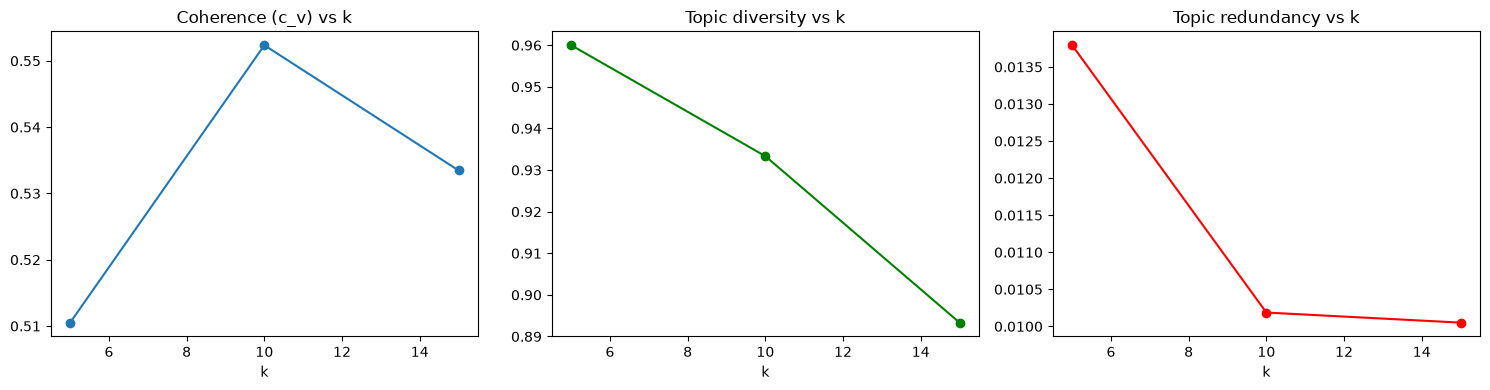

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(summary_df["k"], summary_df["coherence_cv"], marker="o")
axes[0].set_title("Coherence (c_v) vs k")
axes[0].set_xlabel("k")

axes[1].plot(summary_df["k"], summary_df["diversity"], marker="o", color="green")
axes[1].set_title("Topic diversity vs k")
axes[1].set_xlabel("k")

axes[2].plot(summary_df["k"], summary_df["redundancy"], marker="o", color="red")
axes[2].set_title("Topic redundancy vs k")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()

In [ ]:
best_k = pick_best_k(summary_df)
print(f"Best k by coherence: {best_k}")

# Override manually once you've eyeballed the keywords below, e.g.:
# best_k = 15

Best k by coherence: 10


## 1 & 2. Inspect keywords + auto names for the chosen k

In [ ]:
from src.modeling.nmf_topic_modeling import get_topic_keywords, name_topics


chosen = results[best_k]
topic_words = chosen["topic_words"]
topic_names = name_topics(topic_words, n=NAMING_WORDS)

for i, (name, words) in enumerate(zip(topic_names, topic_words), start=1):
    print(f"Topic {i} [{name}]: {', '.join(words)}")

Topic 1 [study / using / data]: study, using, data, used, results, based, significant, analysis, research, factors, findings, methods, method, high, model
Topic 2 [covid / covid_19 / 19]: covid, covid 19, 19, coronavirus, disease, pandemic, 2019, coronavirus disease, disease 2019, coronavirus disease 2019, 2019 covid 19, 2019 covid, disease 2019 covid, outbreak, infectious disease
Topic 3 [sri / lanka / sri_lanka]: sri, lanka, sri lanka, science, political, political science, law, social, sociology, education, business, psychology, economics, computer, computer science
Topic 4 [learning / computer / machine]: learning, computer, machine, artificial, machine learning, intelligence, artificial intelligence, computer science, detection, deep, network, science, deep learning, neural, using
Topic 5 [chemistry / engineering / materials]: chemistry, engineering, materials, materials science, science, composite, material, organic, properties, organic chemistry, composite material, physics, app

## 4. Interpretability — annotation template (fill in `manual_name` / score by hand)

In [ ]:
from src.modeling.nmf_topic_modeling import build_annotation_template

annotation_df = build_annotation_template(topic_words, topic_names, n_words=10)
annotation_df

,topic_id,auto_name,top_words,manual_name,interpretability_score_1to5,notes
0,1,study / using / data,"study, using, data, used, results, based, sign...",,,
1,2,covid / covid_19 / 19,"covid, covid 19, 19, coronavirus, disease, pan...",,,
2,3,sri / lanka / sri_lanka,"sri, lanka, sri lanka, science, political, pol...",,,
3,4,learning / computer / machine,"learning, computer, machine, artificial, machi...",,,
4,5,chemistry / engineering / materials,"chemistry, engineering, materials, materials s...",,,
5,6,medicine / health / internal_medicine,"medicine, health, internal medicine, internal,...",,,
6,7,archaeology / ancient / history,"archaeology, ancient, history, studies, archae...",,,
7,8,கக / கள / தத,"கக, கள, தத, பப, ஆயவ, டட, நத, ணட, றக, றற",,,
8,9,environmental / management / ecology,"environmental, management, ecology, water, env...",,,
9,10,abstract_available / available / abstract,"abstract available, available, abstract, edito...",,,


## 5. Trend analysis — dominant topic per publication, over time

Requires a year column (`publication_year` / `year` / `pub_year` / `date`); adjust `YEAR_COL`
below if yours is named differently.


In [ ]:
from src.modeling.nmf_topic_modeling import assign_dominant_topic, topic_trend_table

YEAR_COL = find_year_column(df.loc[has_text])
print("Detected year column:", YEAR_COL)

dominant, weight = assign_dominant_topic(chosen["W"])

if YEAR_COL:
    counts, shares = topic_trend_table(df.loc[has_text], dominant, YEAR_COL, topic_names)
    display(shares.round(3))
else:
    print("No year column found — set YEAR_COL manually to run this cell.")

Detected year column: publication_year


topic_name,abstract_available / available / abstract,archaeology / ancient / history,chemistry / engineering / materials,covid / covid_19 / 19,environmental / management / ecology,learning / computer / machine,medicine / health / internal_medicine,sri / lanka / sri_lanka,study / using / data,கக / கள / தத
publication_year,,,,,,,,,,
2016,0.013,0.025,0.125,0.002,0.106,0.076,0.208,0.190,0.237,0.019
2017,0.011,0.024,0.113,0.003,0.096,0.081,0.192,0.223,0.226,0.030
2018,0.011,0.022,0.130,0.003,0.111,0.086,0.194,0.184,0.234,0.025
2019,0.013,0.021,0.142,0.006,0.095,0.097,0.161,0.205,0.246,0.014
2020,0.043,0.021,0.128,0.047,0.104,0.094,0.190,0.175,0.189,0.009
2021,0.015,0.020,0.130,0.066,0.097,0.104,0.174,0.190,0.195,0.009
2022,0.015,0.020,0.126,0.054,0.095,0.171,0.160,0.142,0.202,0.014
2023,0.022,0.027,0.124,0.030,0.096,0.183,0.174,0.127,0.208,0.008
2024,0.021,0.031,0.118,0.015,0.093,0.206,0.167,0.099,0.234,0.016


/tmp/ipykernel_46504/1658114815.py:7: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46504/1658114815.py:7: UserWarning: Glyph 2995 (\N{TAMIL LETTER LLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46504/1658114815.py:7: UserWarning: Glyph 2980 (\N{TAMIL LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/asma/Projects/researchlanka-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asma/Projects/researchlanka-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2995 (\N{TAMIL LETTER LLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asma/Projects/researchlanka-ai/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2980 (

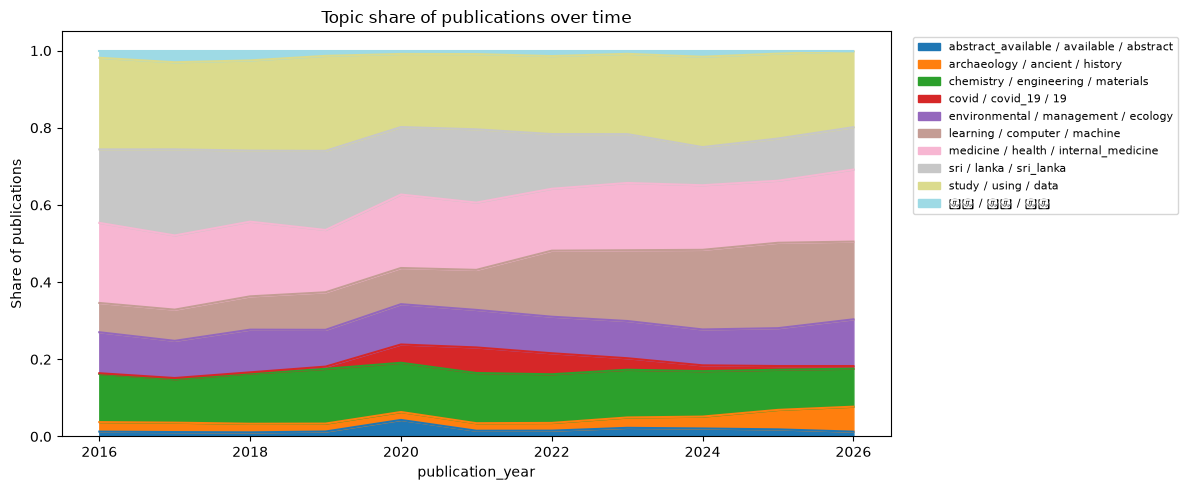

In [ ]:
if YEAR_COL:
    shares.plot(kind="area", stacked=True, figsize=(12, 5), colormap="tab20")
    plt.title("Topic share of publications over time")
    plt.ylabel("Share of publications")
    plt.xlabel(YEAR_COL)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

## Happy with `best_k`? Run the full pipeline + save all artifacts

This calls the same `run_final_pipeline()` that `scripts/run_nmf_pipeline.py` uses, so what you
save here matches what the production script would produce for this k.


In [ ]:
FINAL_K = best_k  # or a number you picked by hand after reading the keywords above

result = run_final_pipeline(
    df=df,
    k=FINAL_K,
    output_dir=OUTPUT_DIR,
    text_columns=TEXT_COLUMNS,
    n_words=N_WORDS,
    naming_words=NAMING_WORDS,
)

## Next: once you're happy with `k`, run for real

```bash
python scripts/run_nmf_pipeline.py \
    --data ../data/processed/common/common_publications_final_with_linearsvm.csv \
    --output-dir ../data/processed/common/nmf \
    --k <FINAL_K>
```

Drop `--k` to have the script re-sweep `--k-range` and auto-pick the best k by coherence instead.
